# Fase 1 — Exploración y limpieza: Superstore Dataset

Objetivo: entender el dataset y dejarlo listo para modelar. Iremos agregando celdas una por una.

## Paso 1 — Imports y librerías

**¿Qué son estas librerías?**
- **pandas**: trabaja con tablas llamadas **DataFrame** (como una hoja de Excel con filas y columnas). Es la base de todo el análisis.
- **numpy**: operaciones matemáticas con números y arrays. pandas está construido sobre numpy.
- **matplotlib.pyplot**: dibuja gráficos (histogramas, barras, líneas).
- **seaborn**: hace gráficos más bonitos y fáciles, construido sobre matplotlib.

**Conceptos clave:**
- `import ... as ...` crea un alias corto para usar la librería (ej: `pd` en lugar de `pandas`).
- `sns.set_theme(style='whitegrid')` fija un estilo visual para todos los gráficos.
- `DATA_PATH` es una **variable constante** con la ruta al archivo CSV. La ruta `../data/` sube un nivel desde la carpeta `notebooks/` y entra a `data/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
DATA_PATH = '../data/superstore.csv'

## Paso 2 — Cargar el CSV y primera inspección

**Conceptos:**
- **CSV**: archivo de texto donde cada línea es una fila y las columnas van separadas por comas.
- **`pd.read_csv()`**: lee el CSV y lo convierte en un **DataFrame** (la tabla de pandas).
- **`df.shape`**: devuelve una tupla `(filas, columnas)`.
- **`df.head()`**: muestra las primeras 5 filas para inspeccionar visualmente.
- **`encoding='latin-1'`**: codificación de caracteres del archivo (acentos, etc.). Sin el encoding correcto, pandas puede fallar o leer caracteres raros.

In [2]:
df = pd.read_csv(DATA_PATH, encoding='latin-1')
print('Filas x columnas:', df.shape)
df.head()

Filas x columnas: (9994, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Paso 3 — Calidad de datos: nulos y duplicados

**Conceptos:**
- **`NaN` (nulo)**: dato que falta en una celda. Deben detectarse porque pueden romper los modelos o sesgar resultados.
- **`df.isna().sum()`**: por cada columna, cuenta cuántos `NaN` hay.
- **Duplicados**: filas exactamente iguales, normalmente errores de carga. `df.duplicated().sum()` las cuenta.
- **Matiz importante**: `Order ID` se repite porque **un pedido puede contener varios productos** (varias filas con el mismo `Order ID`). Eso NO es un duplicado real: es la estructura del dataset.

In [3]:
nulos = df.isna().sum()
print('Nulos por columna:', nulos[nulos > 0].to_dict() if nulos.sum() > 0 else 'Sin nulos')
print('Filas duplicadas:', df.duplicated().sum())
print('Order ID duplicados:', df['Order ID'].duplicated().sum(), '(normal: un pedido tiene varios productos)')

Nulos por columna: Sin nulos
Filas duplicadas: 0
Order ID duplicados: 4985 (normal: un pedido tiene varios productos)


## Paso 4 — Fechas a `datetime` y rango de pedidos

**Conceptos:**
- **`pd.to_datetime()`**: convierte una columna de texto con formato de fecha en un tipo **`datetime`** real. Con fechas "de verdad" pandas puede extraer año/mes/día, ordenar cronológicamente y calcular diferencias entre fechas.
- **`.dt`**: prefijo que se usa para acceder a las propiedades de una columna de fechas (ej: `df['Order Date'].dt.year`).
- **Rango de pedidos**: con `.min()` y `.max()` vemos el período que cubre el dataset.

In [4]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print('Rango de pedidos:', df['Order Date'].min(), 'a', df['Order Date'].max())
df[['Order Date', 'Ship Date']].head()

Rango de pedidos: 2014-01-03 00:00:00 a 2017-12-30 00:00:00


,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


## Paso 5 — Estadísticas básicas y distribución de `Sales`

**Conceptos:**
- **`df['Sales'].describe()`**: resumen estadístico con media, desvío estándar y percentiles (25%, 50%, 75%).
- **Media vs mediana**: si la media (229.86) es mucho mayor que la mediana (54.49), la distribución está **sesgada a la derecha**: hay pocos pedidos muy caros que "jalan" la media hacia arriba.
- **Histograma** (`sns.histplot`): cuenta cuántos valores caen en cada rango.
- **`np.log1p(x)` = log(1+x)**: transformación logarítmica que "aplana" distribuciones muy sesgadas para poder verlas mejor. Es útil también como variable objetivo del modelo.

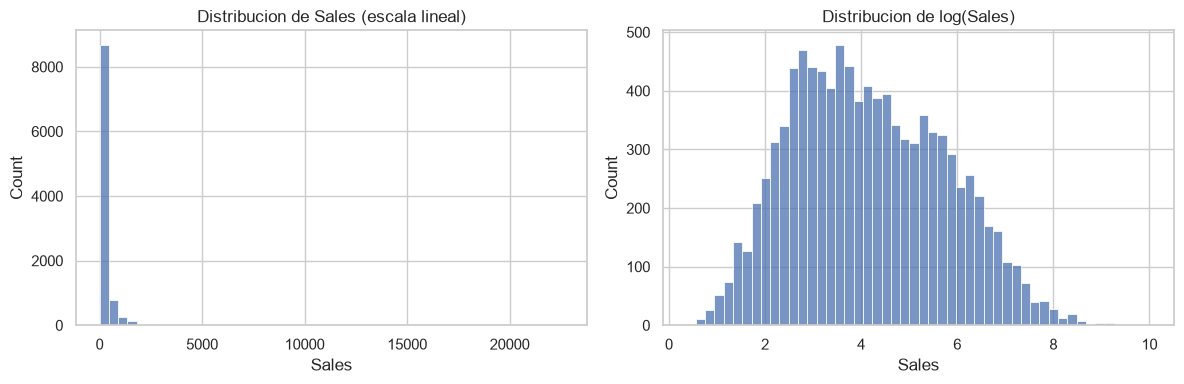

In [5]:
df['Sales'].describe()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Sales'], bins=50, ax=axes[0])
axes[0].set_title('Distribucion de Sales (escala lineal)')
sns.histplot(np.log1p(df['Sales']), bins=50, ax=axes[1])
axes[1].set_title('Distribucion de log(Sales)')
plt.tight_layout()
plt.show()

## Paso 6 — Ventas por categoría, región y segmento

**Conceptos:**
- **`value_counts()`**: cuenta cuántas veces aparece cada valor de una columna categórica.
- **`sns.barplot`**: gráfico de barras que compara magnitudes entre categorías.
- Comparar cuántos pedidos hay por categoría/región/segmento nos dice dónde se concentra el negocio.

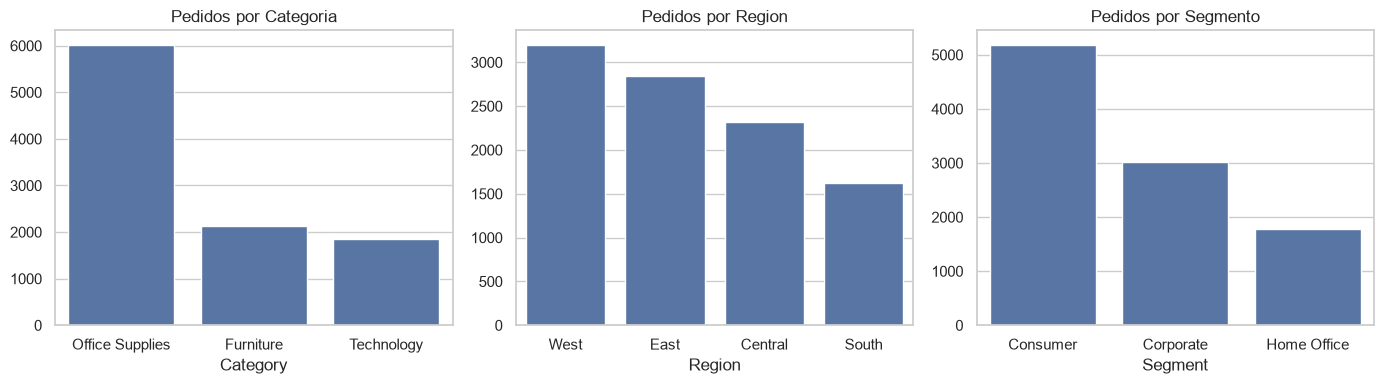

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.barplot(x=df['Category'].value_counts().index, y=df['Category'].value_counts().values, ax=axes[0])
axes[0].set_title('Pedidos por Categoria')

sns.barplot(x=df['Region'].value_counts().index, y=df['Region'].value_counts().values, ax=axes[1])
axes[1].set_title('Pedidos por Region')

sns.barplot(x=df['Segment'].value_counts().index, y=df['Segment'].value_counts().values, ax=axes[2])
axes[2].set_title('Pedidos por Segmento')

plt.tight_layout()
plt.show()

## Paso 7 — Evolución temporal de las ventas

**Conceptos:**
- **`.dt.to_period('M')`**: convierte cada fecha al período mensual al que pertenece (ej: "2016-11"). Sirve para agrupar por mes.
- **`groupby(...)['Sales'].sum()`**: suma las ventas de cada grupo (mes).
- **Gráfico de líneas**: muestra tendencia y estacionalidad (¿picos en alguna época del año?).

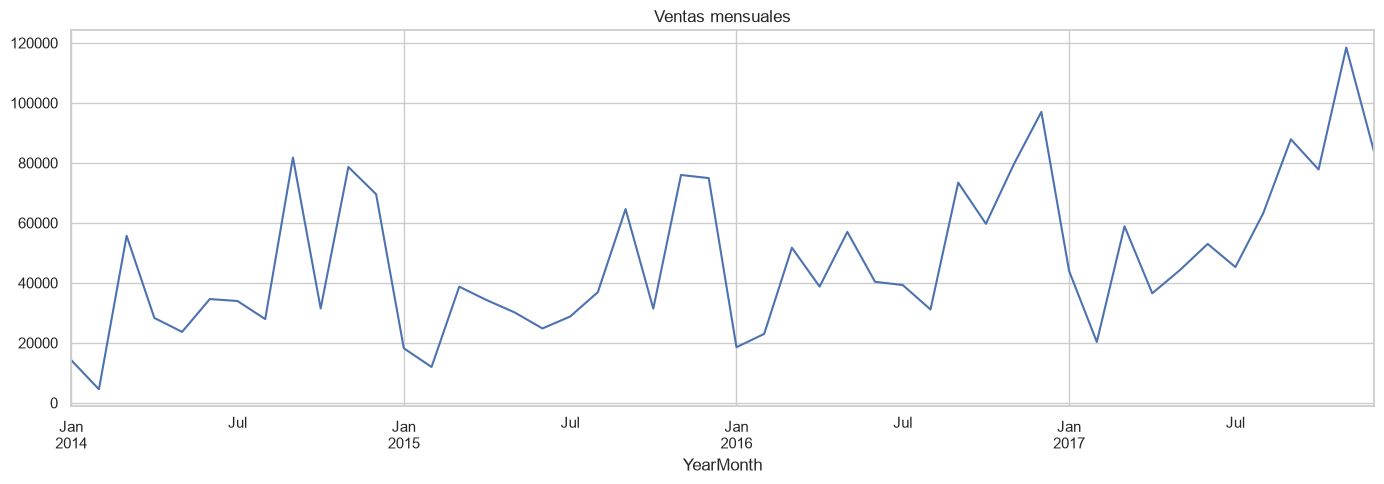

Pedidos por año:


Order Date
2014    1993
2015    2102
2016    2587
2017    3312
dtype: int64

In [7]:
df['YearMonth'] = df['Order Date'].dt.to_period('M')
ventas_mensuales = df.groupby('YearMonth')['Sales'].sum()

ventas_mensuales.plot(figsize=(14, 5), title='Ventas mensuales')
plt.tight_layout()
plt.show()

print('Pedidos por año:')
df.groupby(df['Order Date'].dt.year).size()

## Paso 8 — Rentabilidad por sub-categoría

**Conceptos:**
- **`groupby('Sub-Category')['Profit'].sum()`**: suma el profit por cada sub-categoría.
- **`sort_values()` + `plot(kind='barh')`**: barras horizontales ordenadas de menor a mayor, para ver fácilmente las que pierden vs. las que ganan.
- **Hallazgo clásico de este dataset**: sub-categorías como Tables o Bookcases venden mucho pero pierden dinero (profit negativo).

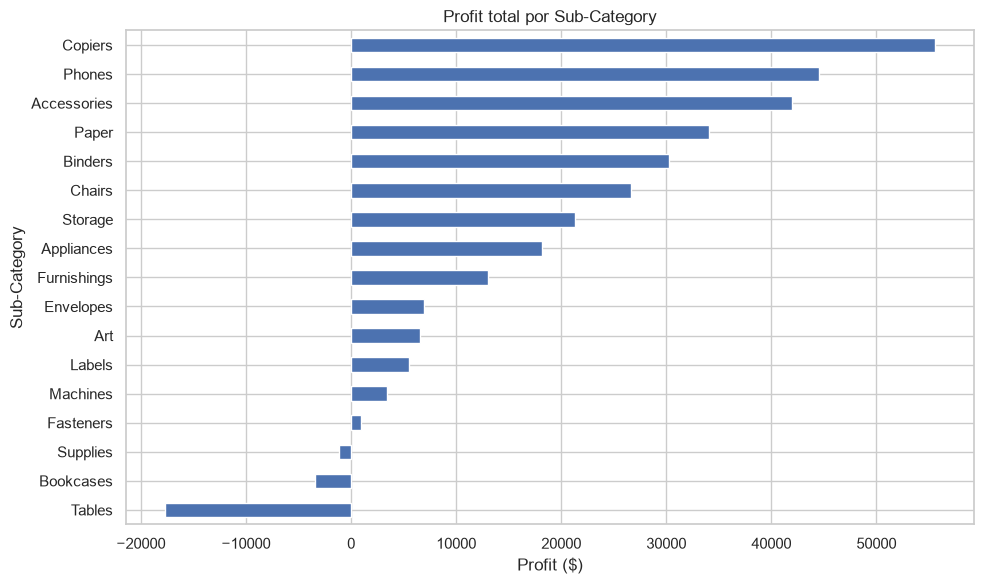

Las 3 que MÁS pierden: ['Tables', 'Bookcases', 'Supplies']
Las 3 que MÁS ganan: ['Accessories', 'Phones', 'Copiers']


In [8]:
profit_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values()

profit_sub.plot(kind='barh', figsize=(10, 6), title='Profit total por Sub-Category')
plt.xlabel('Profit ($)')
plt.tight_layout()
plt.show()

print('Las 3 que MÁS pierden:', list(profit_sub.head(3).index))
print('Las 3 que MÁS ganan:', list(profit_sub.tail(3).index))

## Paso 9 — Feature engineering

**Conceptos:**
- **Feature engineering**: crear nuevas columnas (features) que ayuden al modelo a aprender.
- **`.dt.year` / `.dt.month` / `.dt.dayofweek`**: extraen componentes de la fecha (año, mes, día de la semana: 0=lunes ... 6=domingo).
- **`IsDiscounted`**: variable binaria (1 si hubo descuento, 0 si no).
- **One-hot encoding** (`pd.get_dummies`): convierte categóricas de baja cardinalidad (Segment, Category, Region, Ship Mode) en columnas 0/1, porque los modelos de ML no entienden texto.

In [9]:
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['DayOfWeek'] = df['Order Date'].dt.dayofweek
df['IsDiscounted'] = (df['Discount'] > 0).astype(int)

dummies = pd.get_dummies(df[['Segment', 'Category', 'Region', 'Ship Mode']], prefix_sep='_', dtype=int)
df = pd.concat([df, dummies], axis=1)

print('Dimensiones tras feature engineering:', df.shape)
df.head()

Dimensiones tras feature engineering: (9994, 40)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category_Office Supplies,Category_Technology,Region_Central,Region_East,Region_South,Region_West,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0,0,0,0,1,0,0,0,1,0
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,0,0,0,0,1,0,0,0,1,0
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,1,0,0,0,0,1,0,0,1,0
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,0,0,0,0,1,0,0,0,0,1
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,1,0,0,0,1,0,0,0,0,1


## Paso 10 — Guardar dataset limpio

**Conceptos:**
- **`to_csv(index=False)`**: guarda el DataFrame a CSV sin la columna de índice, para no añadir basura.
- Este archivo `superstore_clean.csv` será la entrada de la **Fase 2 (ML)**: entrenaremos el modelo predictivo sobre estas columnas.

In [10]:
df.to_csv('../data/superstore_clean.csv', index=False)
print('Guardado: data/superstore_clean.csv')
print('Filas:', df.shape[0], '| Columnas:', df.shape[1])

Guardado: data/superstore_clean.csv
Filas: 9994 | Columnas: 40


# Fase 2 — Modelo predictivo de ventas

> El objetivo: predecir cuánto venderá un pedido dada su categoría, región, descuento, etc.
> Entrenamos dos modelos y nos quedamos con el mejor.

## Paso 11 — Preparar datos para ML

**Conceptos:**
- **`np.log1p(x)` = log(1+x)**: transformamos `Sales` a escala logarítmica porque está muy sesgada. Al predecir en log y luego invertir con `np.expm1()`, el modelo comete menos errores en los pedidos pequeños.
- **`train_test_split`**: divide aleatoriamente 80% para entrenar y 20% para evaluar. `random_state=42` garantiza reproducibilidad.
- **`FEATURES`**: las 20 columnas que usará el modelo. Las categóricas ya fueron convertidas a 0/1 en el Paso 9.

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

FEATURES = [
    "Quantity", "Discount", "Year", "Month", "DayOfWeek", "IsDiscounted",
    "Segment_Consumer", "Segment_Corporate", "Segment_Home Office",
    "Category_Furniture", "Category_Office Supplies", "Category_Technology",
    "Region_Central", "Region_East", "Region_South", "Region_West",
    "Ship Mode_First Class", "Ship Mode_Same Day", "Ship Mode_Second Class", "Ship Mode_Standard Class",
]

X = df[FEATURES]
y_log = np.log1p(df["Sales"])

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")
print(f"Features: {len(FEATURES)}")

Train: 7995 | Test: 1999
Features: 20


## Paso 12 — Baseline: LinearRegression

**Conceptos:**
- **LinearRegression**: ajusta una línea recta que minimiza el error cuadrático medio entre predicción y valor real. Es el piso de referencia más simple.
- **`np.expm1()`**: inversión de `log1p`. Como entrenamos en escala log, predecimos en log y luego convertimos de vuelta a dólares.
- **MAE**: error absoluto medio en dólares. Dice "en promedio nos equivocamos por ±$X".
- **RMSE**: raíz del error cuadrático medio. Pega más a los errores grandes.
- **R²**: proporción de la varianza de `y` que el modelo explica. 1.0 es perfecto, 0 significa que no explica nada.

In [12]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = np.expm1(lr.predict(X_test))
y_test_orig = np.expm1(y_test)

mae_lr = mean_absolute_error(y_test_orig, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test_orig, y_pred_lr))
r2_lr = r2_score(y_test_orig, y_pred_lr)

print("LinearRegression (baseline):")
print(f"  MAE  : ${mae_lr:.2f}")
print(f"  RMSE : ${rmse_lr:.2f}")
print(f"  R²   : {r2_lr:.4f}")

LinearRegression (baseline):


  MAE  : $205.84
  RMSE : $757.47
  R²   : 0.0287


## Paso 13 — Random Forest

**Conceptos:**
- **RandomForest**: ensemble de 100 árboles de decisión, cada uno entrenado con una muestra diferente de los datos. El resultado promedio reduce el overfitting que tendría un solo árbol.
- `n_estimators=100`: 100 árboles.
- `n_jobs=-1`: usa todos los núcleos del CPU para entrenar más rápido.
- Normalmente supera a LinearRegression en datos con relaciones no lineales.

In [13]:
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = np.expm1(rf.predict(X_test))

mae_rf = mean_absolute_error(y_test_orig, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test_orig, y_pred_rf))
r2_rf = r2_score(y_test_orig, y_pred_rf)

print("RandomForest:")
print(f"  MAE  : ${mae_rf:.2f}")
print(f"  RMSE : ${rmse_rf:.2f}")
print(f"  R²   : {r2_rf:.4f}")

RandomForest:
  MAE  : $203.34
  RMSE : $749.34
  R²   : 0.0494


## Paso 14 — Comparación y feature importance

**Conceptos:**
- **Feature importance**: cuánto aporta cada feature a reducir el error en los árboles del Random Forest. Las más importantes son las que más influyen en predecir `Sales`.
- Comparar MAE/RMSE/R² de ambos modelos para decidir cuál usar.

COMPARACION DE MODELOS
Modelo                    MAE ($)   RMSE ($)       R²
--------------------------------------------------
LinearRegression           205.84     757.47   0.0287
RandomForest               203.34     749.34   0.0494
--------------------------------------------------
Mejor: RandomForest


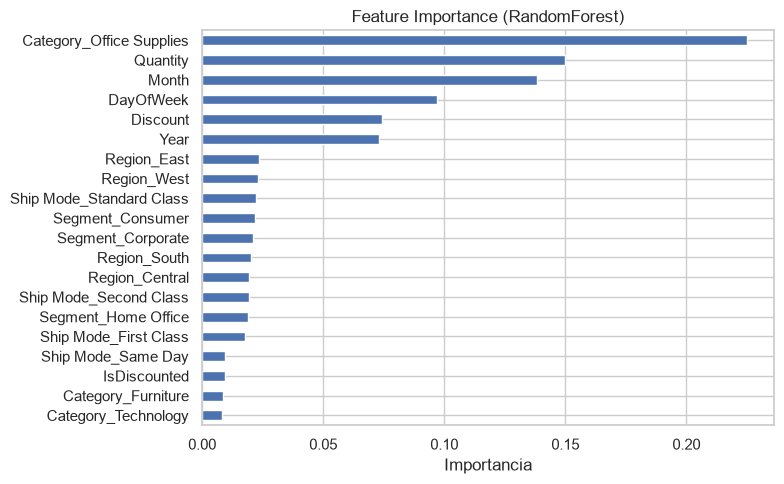

In [14]:
print("=" * 50)
print("COMPARACION DE MODELOS")
print("=" * 50)
print(f"{'Modelo':<22} {'MAE ($)':>10} {'RMSE ($)':>10} {'R²':>8}")
print("-" * 50)
print(f"{'LinearRegression':<22} {mae_lr:>10.2f} {rmse_lr:>10.2f} {r2_lr:>8.4f}")
print(f"{'RandomForest':<22} {mae_rf:>10.2f} {rmse_rf:>10.2f} {r2_rf:>8.4f}")
print("-" * 50)
best = "RandomForest" if r2_rf > r2_lr else "LinearRegression"
print(f"Mejor: {best}")

fig, ax = plt.subplots(figsize=(8, 5))
importance = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)
importance.plot(kind='barh', ax=ax)
ax.set_title('Feature Importance (RandomForest)')
ax.set_xlabel('Importancia')
plt.tight_layout()
plt.show()

## Paso 15 — Guardar modelo

**Conceptos:**
- **`joblib.dump(model, path)`**: guarda el modelo entrenado a disco. Permite cargarlo después sin volver a entrenar (clave para la API de FastAPI en la Fase 3).

In [15]:
best_model = rf if r2_rf > r2_lr else lr
joblib.dump(best_model, '../ml/model.pkl')
print(f"Modelo guardado: ml/model.pkl")
print(f"Tipo: {type(best_model).__name__}")
print(f"R² del modelo elegido: {max(r2_lr, r2_rf):.4f}")

Modelo guardado: ml/model.pkl
Tipo: RandomForestRegressor
R² del modelo elegido: 0.0494
